# Práctica Académica: Normalización y Estandarización de Datos en IA
**Estudiante:** Omar Recalde  
**Profesor:** Elvis Pachacama  
**Materia:** Machine Learning  
**Fecha:** 05/05/2026  
**Repositorio GitHub:** https://github.com/OmaRecalde/machinelearning2026  

---
### Objetivo General
Aplicar técnicas de normalización y es tandarización de datos mediante herramientas de Python para comprender su impacto en la preparación de datos y en el desempeño de modelos de aprendizaje automático.

In [2]:
import pandas as pd
import numpy as np
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
import os

# Configuración opcional para descargas desde Kaggle
os.environ['KAGGLE_CONFIG_DIR'] = "C:/Users/ADMIN-ITQ/.kaggle"
os.makedirs("dataset", exist_ok=True)

In [3]:
# Carga del archivo Iris.csv (asumiendo que está descomprimido o disponible en el directorio dataset)
try:
    with zipfile.ZipFile("iris.zip", 'r') as zip_ref:
        zip_ref.extractall("dataset")
    df = pd.read_csv("dataset/Iris.csv")
except FileNotFoundError:
    # Carga alternativa directa o mediante seaborn si el archivo zip no está presente físicamente
    try:
        df = pd.read_csv("dataset/Iris.csv")
    except FileNotFoundError:
        df = sns.load_dataset('iris')
        df.columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Eliminamos la columna 'Id' ya que no aporta al modelo de Machine Learning
if 'Id' in df.columns:
    df = df.drop(columns=["Id"])

print("--- Información del Dataset ---")
df.info()

print("\n--- Verificación de Valores Nulos ---")
print(df.isnull().sum())

# Separación de características de entrada (X) y variable objetivo (y)
X = df.drop(columns=['Species'])
y = df['Species']

X.head()

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- Verificación de Valores Nulos ---
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# Exploramos las estadísticas descriptivas del conjunto de datos de entrada
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 💡 Conclusión del Análisis Exploratorio

Cuando observamos la tabla estadística, se evidencia que cada variable presenta magnitudes y rangos diferentes:
* **PetalLengthCm:** Varía sensiblemente desde $1.0$ hasta $6.9$ cm.
* **SepalWidthCm:** Muestra menor dispersión, moviéndose aproximadamente entre $2.0$ y $4.4$ cm.

**¿Qué significa esto?**
En algoritmos basados en distancias (como KNN o SVM), las variables con magnitudes numéricas más grandes dominan el cálculo del modelo. Si no realizamos un escalado previo, las decisiones del algoritmo estarán sesgadas hacia `PetalLengthCm`, ignorando el aporte de otras variables[cite: 1].

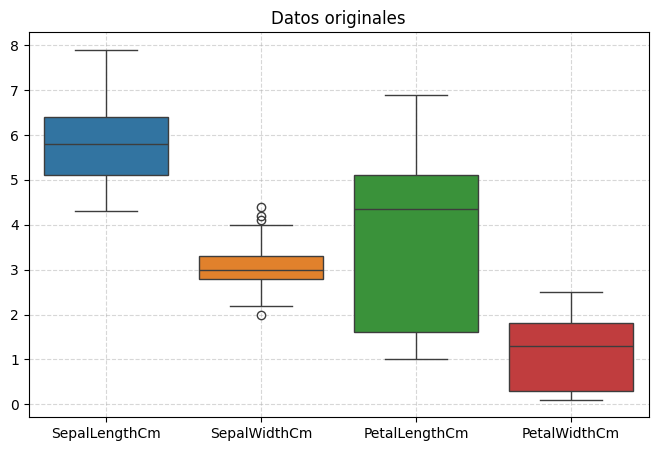

In [6]:
# Dibujamos los datos originales para visualizar el sesgo de escala
plt.figure(figsize=(8, 5))
sns.boxplot(data=X)
plt.title("Datos originales")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 🖼️ Interpretación del Gráfico
Este gráfico de caja permite confirmar visualmente que los datos originales no comparten la misma escala[cite: 1]. Se aprecia una variabilidad dispar entre las variables, lo que valida la necesidad técnica de aplicar **Normalización** o **Estandarización** para equilibrar el peso de cada característica[cite: 1].

In [7]:
# Normalizamos el conjunto de datos al rango [0, 1]
normalizer = preprocessing.MinMaxScaler()
X_norm = normalizer.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)

# Visualizamos las primeras filas normalizadas
X_norm.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [8]:
# Verificamos los rangos [0, 1] tras la normalización
X_norm.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.440556,0.467458,0.458056
std,0.230018,0.181611,0.299203,0.317599
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [9]:
# Estandarizamos los datos para obtener Media=0 y Desviación Estándar=1
standarizer = preprocessing.StandardScaler()
X_std = standarizer.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns)

# Visualizamos las primeras filas estandarizadas
X_std.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [10]:
# Verificamos la media (0) y desviación estándar (1)
X_std.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


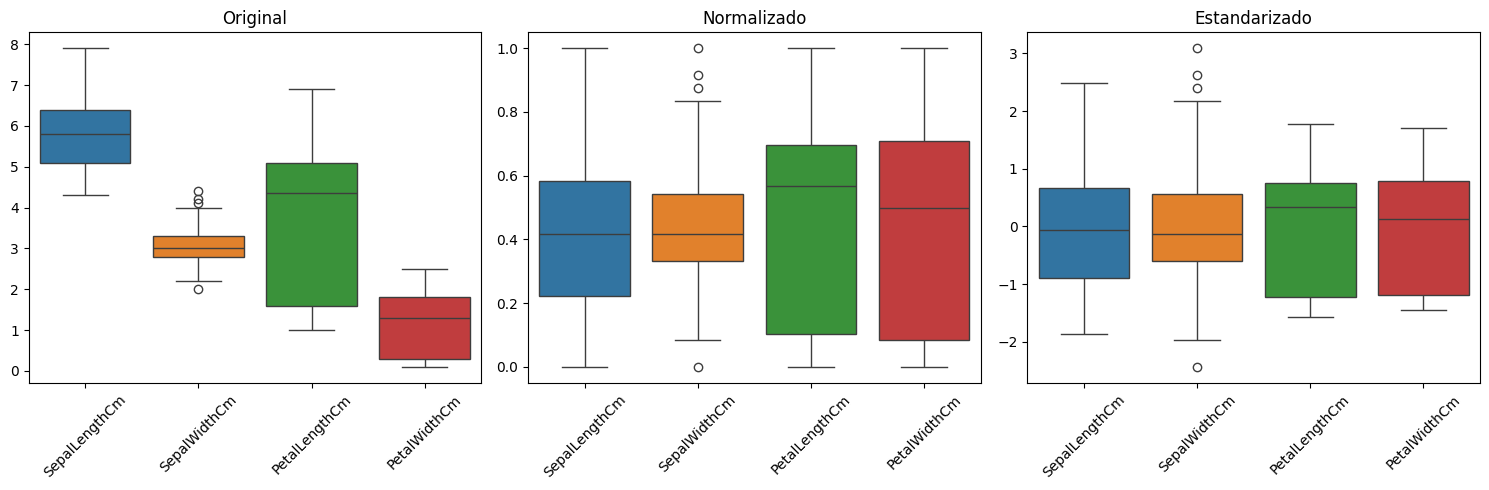

In [11]:
# Comparación visual entre datos Originales, Normalizados y Estandarizados
plt.figure(figsize=(15, 5))

# Plot 1: Datos Originales
plt.subplot(1, 3, 1)
sns.boxplot(data=X)
plt.title("Original")
plt.xticks(rotation=45)

# Plot 2: Datos Normalizados (MinMax)
plt.subplot(1, 3, 2)
sns.boxplot(data=X_norm)
plt.title("Normalizado")
plt.xticks(rotation=45)

# Plot 3: Datos Estandarizados (Z-Score)
plt.subplot(1, 3, 3)
sns.boxplot(data=X_std)
plt.title("Estandarizado")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 📝 Conclusiones Finales

1. **Impacto de la Normalización ($Min-Max$):**
   * Transforma todas las características al rango estricto $[0, 1]$[cite: 1].
   * Es la opción ideal cuando se conocen los límites superior e inferior de los datos y la distribución no es necesariamente gaussiana.

2. **Impacto de la Estandarización ($Z-Score$):**
   * Reorganiza los datos para centrar la media en $0$ y ajustar la desviación estándar a $1$[cite: 1].
   * Es más robusta frente a la presencia de valores atípicos (*outliers*) y resulta esencial para algoritmos que asumen distribuciones normales o emplean cálculos de distancia/optimizadores de gradiente (como SVM, Regresión Logística y Redes Neuronales)[cite: 1].

3. **Criterio Selección del Escalado:**
   * Al eliminar las diferencias de magnitud, se evita que variables con rangos altos (como `PetalLengthCm`) dominen el comportamiento predictivo sobre variables con rangos más acotados (como `SepalWidthCm`)[cite: 1].